# Lab 10 — Resposta em Frequência, Diagrama de Bode e Margens

**Módulo 03 · Semana 10 · Laboratório de Controle Automático (Ifes Guarapari)**

Neste laboratório você vai:
1. **Ver o teorema da resposta em frequência acontecer** num circuito RC simulado;
2. Construir o **diagrama de Bode exato × assintótico** e conferir o erro de 3 dB nas quebras;
3. Ler **PM e GM** no Bode e relacionar PM com overshoot ($\mathrm{PM} \approx 100\,\zeta$);
4. **Projetar um controlador P pela margem de fase** e validar por simulação.

Teoria de referência: `teoria_modulo3.md`, seção **§3.1** (figuras `m3_fig01` a `m3_fig07`).

In [1]:
# %% IMPORTS (rode esta célula primeiro)
!pip install --quiet control==0.10.2
import control as ct
import numpy as np
import matplotlib.pyplot as plt
import math
plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.grid'] = True

def step(G, t):
    t, y = ct.step_response(G, t)
    return np.asarray(t), np.asarray(y)   # python-control 0.10.2: converte NamedSignal

def medir(T, t=None):
    # Mede Mp (%), tp, tr(0-100%) e ts(5%) da resposta ao degrau de T.
    if t is None: t = np.linspace(0, 50, 20000)
    t, y = step(T, t)
    yss = y[-1]
    Mp = 100*(y.max() - yss)/yss
    tp = t[np.argmax(y)]
    tr = t[np.argmax(y >= yss)]
    fora = np.where(np.abs(y - yss) > 0.05*abs(yss))[0]
    ts = t[fora[-1]] if len(fora) else 0.0
    return dict(Mp=Mp, tp=tp, tr=tr, ts=ts, yss=yss)

def mp(G, w):
    # Módulo (vezes) e fase (graus) de G em w (rad/s).
    mag, ph, _ = ct.frequency_response(G, np.atleast_1d(w))
    return np.asarray(mag).ravel(), np.degrees(np.asarray(ph).ravel())

def mf(G):
    return ct.feedback(G, 1)

print('python-control', ct.__version__)


[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: pip install --upgrade pip


python-control 0.10.2


## Parte 1 — O teorema da resposta em frequência ao vivo

O circuito RC de referência do curso tem $G(s) = \dfrac{1}{0{,}1034\,s + 1}$ (quebra em $\omega_q = 1/0{,}1034 = 9{,}67$ rad/s).
Vamos injetar senoides de **amplitude 1** em $\omega = 1$, $10$ e $100$ rad/s e medir amplitude e defasagem da saída **em regime** (último período).

> **Teorema (§3.1.3):** $y_{rp}(t) = A\,|G(j\omega)|\,\mathrm{sen}\big(\omega t + \angle G(j\omega)\big)$ — mesma frequência, amplitude escalada por $|G|$, fase deslocada por $\angle G$.

G(s) =
<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

       1
  ------------
  0.1034 s + 1


w =   1 rad/s | medido: A = 0.995, fase =   -5.9° | teoria: |G| = 0.995, fase G =   -5.9°
w =  10 rad/s | medido: A = 0.695, fase =  -46.0° | teoria: |G| = 0.695, fase G =  -46.0°


w = 100 rad/s | medido: A = 0.096, fase =  -84.9° | teoria: |G| = 0.096, fase G =  -84.5°


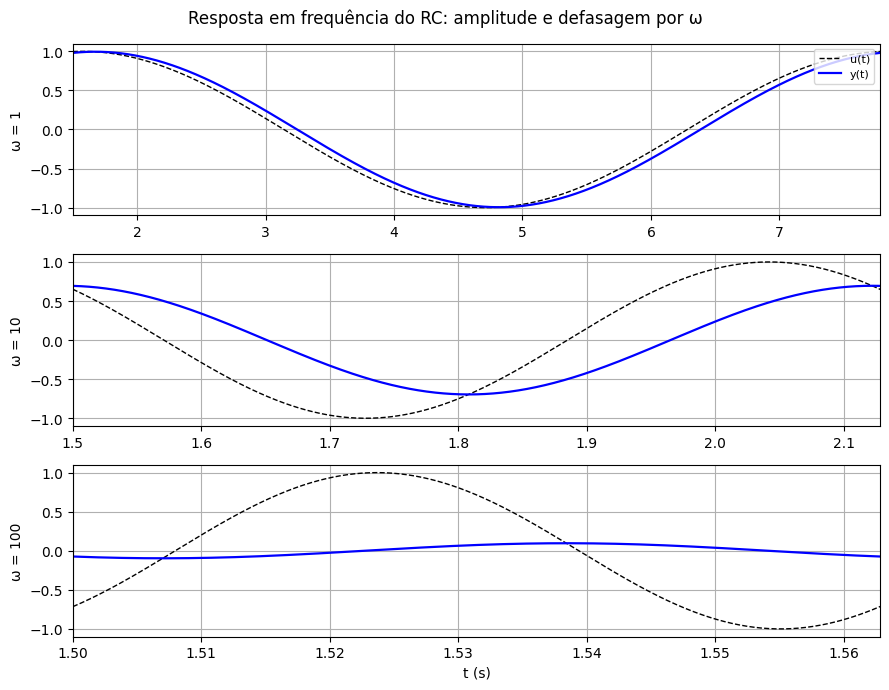

In [2]:
G = ct.tf([1], [0.1034, 1])
print('G(s) ='); print(G)

fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=False)
for k, w0 in enumerate([1, 10, 100]):
    T = 2*np.pi/w0
    t = np.linspace(0, 5*T + 2, 20000)   # +2 s: mata o transitório (τ = 0,1034 s)
    u = np.sin(w0*t)
    resp = ct.forced_response(G, t, u)
    y = np.asarray(resp.outputs)
    m = t > 1.5                     # regime: transitório morto (≈ 15τ)
    Aout = (y[m].max() - y[m].min())/2
    tm, ym, um = t[m], y[m], u[m]
    iu = np.where((um[:-1] < 0) & (um[1:] >= 0))[0][0]   # cruzamento ascendente da entrada
    iy = np.where((ym[:-1] < 0) & (ym[1:] >= 0))[0][0]   # ... e da saída
    phi = -np.degrees((tm[iy] - tm[iu])*w0)              # atraso → fase negativa
    phi = ((phi + 180) % 360) - 180                     # enrola para (-180, 180]
    mT, pT = mp(G, w0)
    print(f'w = {w0:>3} rad/s | medido: A = {Aout:.3f}, fase = {phi:6.1f}° | '
          f'teoria: |G| = {mT[0]:.3f}, fase G = {pT[0]:6.1f}°')
    ax = axes[k]
    ax.plot(t, u, 'k--', lw=1, label='u(t)')
    ax.plot(t, y, 'b', lw=1.6, label='y(t)')
    ax.set_xlim(1.5, 1.5 + T); ax.set_ylabel(f'ω = {w0}')
    if k == 0: ax.legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('t (s)')
fig.suptitle('Resposta em frequência do RC: amplitude e defasagem por ω')
plt.tight_layout(); plt.show()

### ✏️ Responda no relatório

**Q1.1** Monte uma tabela com os valores medidos e os teóricos ($|G(j\omega)|$, $\angle G(j\omega)$) para as três frequências. Os erros são compatíveis com a precisão da medição gráfica?

**Q1.2** Por que a defasagem deste sistema nunca passa de $-90°$? Quantos graus, no máximo, cada polo e cada zero podem contribuir?

**Q1.3** Em $\omega = 100$ rad/s a saída ainda é senoidal? O que mudou em relação a $\omega = 1$? Onde isso aparece no diagrama de Bode?

## Parte 2 — Bode exato × assintótico e o erro de 3 dB

Seja $G(s) = \dfrac{10}{s(s+2)} = \dfrac{5}{s\,(s/2+1)}$ — um integrador mais um polo em $-2$ (a planta da figura `m3_fig04`).
O código abaixo traça o Bode **exato** e sobrepõe as **assíntotas** da convenção do curso (fase por retas de $\omega_q/5$ a $5\omega_q$).

Na quebra ω=2: exato = 4.95 dB | assíntota = 7.96 dB → erro = -3.01 dB (regra dos 3 dB ✓)


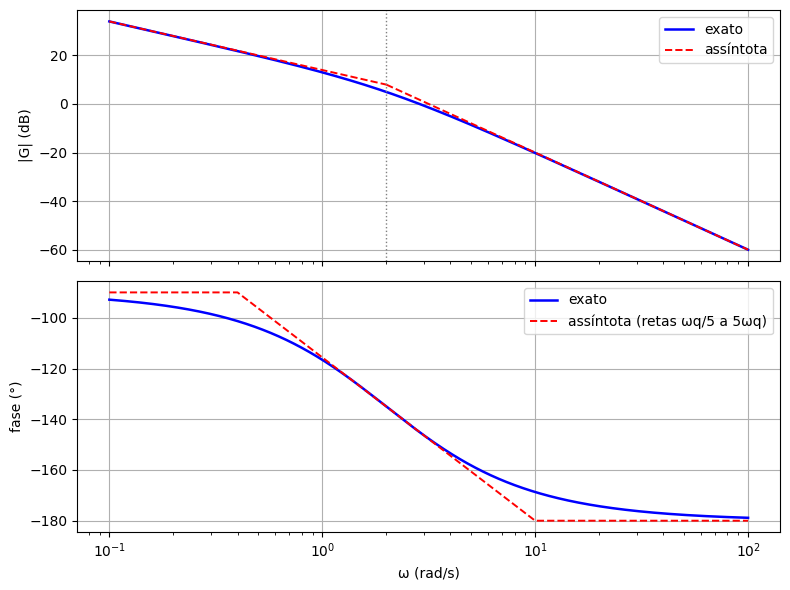


ωc = 2.87 rad/s  →  PM = 34.9°
A fase tende a -180° sem nunca chegar lá → GM = ∞ (este sistema não desestabiliza por ganho)
Estimativa: PM ≈ 100ζ → ζ ≈ 0.35 → Mp ≈ 31.0%
Simulação da malha fechada: Mp = 35.1%,  tr = 0.63 s


In [3]:
G = ct.tf([10], [1, 2, 0])
w = np.logspace(-1, 2, 2000)
m, p = mp(G, w)
mdb = 20*np.log10(m)

# assíntotas de módulo: 5/ω (declive -20) até ω=2; 10/ω² (declive -40) depois
w1 = np.array([0.1, 2]);   m1 = 20*np.log10(5/w1)
w2 = np.array([2, 100]);   m2 = 20*np.log10(10/w2**2)
# assíntota de fase: -90° até 0,4; reta até -180° em 10; -180° depois
wf = np.array([0.1, 0.4, 10, 100]); pf = np.array([-90, -90, -180, -180])

fig, (axm, axf) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axm.semilogx(w, mdb, 'b', lw=1.8, label='exato')
axm.semilogx(w1, m1, 'r--', lw=1.4, label='assíntota')
axm.semilogx(w2, m2, 'r--', lw=1.4)
axm.axvline(2, color='gray', ls=':', lw=1)
m2q, _ = mp(G, 2)
print(f'Na quebra ω=2: exato = {20*np.log10(m2q[0]):.2f} dB | assíntota = {20*np.log10(2.5):.2f} dB '
      f'→ erro = {20*np.log10(m2q[0]/2.5):.2f} dB (regra dos 3 dB ✓)')
axm.set_ylabel('|G| (dB)'); axm.legend()
axf.semilogx(w, p, 'b', lw=1.8, label='exato')
axf.semilogx(wf, pf, 'r--', lw=1.4, label='assíntota (retas ωq/5 a 5ωq)')
axf.set_ylabel('fase (°)'); axf.set_xlabel('ω (rad/s)'); axf.legend()
plt.tight_layout(); plt.show()

# margens
iwc = np.argmin(np.abs(mdb)); wc = w[iwc]
print(f'\nωc = {wc:.2f} rad/s  →  PM = {p[iwc]+180:.1f}°')
print('A fase tende a -180° sem nunca chegar lá → GM = ∞ (este sistema não desestabiliza por ganho)')
r = medir(mf(G), np.linspace(0, 20, 20000))
print(f'Estimativa: PM ≈ 100ζ → ζ ≈ {(p[iwc]+180)/100:.2f} → Mp ≈ {100*math.exp(-math.pi*(p[iwc]+180)/100/math.sqrt(1-((p[iwc]+180)/100)**2)):.1f}%')
print(f'Simulação da malha fechada: Mp = {r["Mp"]:.1f}%,  tr = {r["tr"]:.2f} s')

### ✏️ Responda no relatório

**Q2.1** Confira no gráfico: qual o erro entre a curva exata e a assíntota de módulo em $\omega = 2$? E o erro máximo da fase assintótica (compare em $\omega = 0{,}4$ e $\omega = 10$)?

**Q2.2** O que significa, fisicamente, $\mathrm{GM} = \infty$? Esse sistema pode ficar instável aumentando-se apenas o ganho?

**Q2.3** Compare a estimativa $\mathrm{PM} \approx 100\,\zeta \to M_p$ com o $M_p$ simulado. De onde vem a pequena diferença? (Dica: a fórmula supõe 2ª ordem pura sem zeros — vale aqui?)

## Parte 3 — Projeto de controlador P pela margem de fase

**Problema:** para $G(s) = \dfrac{5}{s(s+5)}$, escolher $K$ tal que a malha fechada tenha $M_p \leq 25\,\%$.

**Receita (§3.1.10):** (i) $M_p \leq 25\,\% \Rightarrow \mathrm{PM}$ alvo $= 45°$ (com folga);
(ii) achar $\omega$ onde $\angle G = -180° + 45° = -135°$ — será a nova $\omega_c$;
(iii) $K = 1/|G(j\omega_c)|$ — o ganho só **desliza a curva de módulo na vertical**, sem tocar a fase.

fase = -135° em ω = 5.00 rad/s (analítico: arctg(ω/5)=45° → ω=5 ✓)
|G(j5.00)| = 0.1416 → K = 7.06  (17.0 dB de aumento)


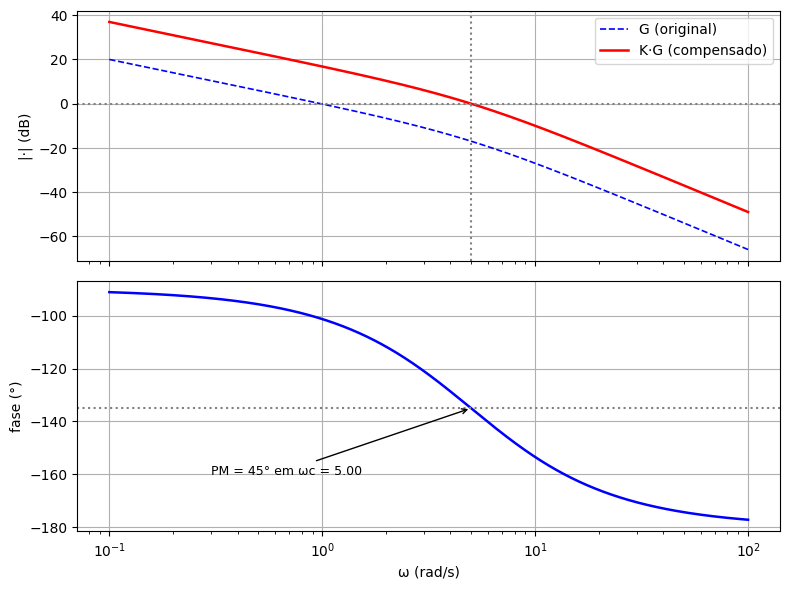


Simulação da malha fechada: Mp = 23.3%  (requisito: ≤ 25%)


In [4]:
G = ct.tf([5], [1, 5, 0])
w = np.logspace(-1, 2, 3000)
m, p = mp(G, w)
i135 = np.argmin(np.abs(p + 135))
wc_novo = w[i135]
print(f'fase = -135° em ω = {wc_novo:.2f} rad/s (analítico: arctg(ω/5)=45° → ω=5 ✓)')
K = 1/m[i135]
print(f'|G(j{wc_novo:.2f})| = {m[i135]:.4f} → K = {K:.2f}  ({20*np.log10(K):.1f} dB de aumento)')

fig, (axm, axf) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
mc, pc = mp(K*G, w)
axm.semilogx(w, 20*np.log10(m), 'b--', lw=1.2, label='G (original)')
axm.semilogx(w, 20*np.log10(mc), 'r', lw=1.8, label='K·G (compensado)')
axm.axhline(0, color='gray', ls=':'); axm.axvline(wc_novo, color='gray', ls=':')
axm.set_ylabel('|·| (dB)'); axm.legend()
axf.semilogx(w, p, 'b', lw=1.8); axf.axhline(-135, color='gray', ls=':')
axf.set_ylabel('fase (°)'); axf.set_xlabel('ω (rad/s)')
axf.annotate(f'PM = 45° em ωc = {wc_novo:.2f}', xy=(wc_novo, -135), xytext=(0.3, -160),
             arrowprops=dict(arrowstyle='->'), fontsize=9)
plt.tight_layout(); plt.show()

r = medir(mf(K*G), np.linspace(0, 6, 20000))
print(f'\nSimulação da malha fechada: Mp = {r["Mp"]:.1f}%  (requisito: ≤ 25%)')

### ✏️ Responda no relatório

**Q3.1** De quantos dB a curva de módulo subiu? Qual a relação com $K$?

**Q3.2** Refaça o projeto para $\mathrm{PM} = 60°$: qual a nova $\omega_c$ e o novo $K$? (Analítico: $\mathrm{arctg}(\omega/5) = 30°$.) O sistema ficou mais rápido ou mais lento? Por quê?

**Q3.3** Por que o ajuste de ganho **não altera a curva de fase**? Escreva $K\,G(j\omega)$ em notação fasorial e justifique.

---

## Encerramento

Neste lab você verificou na prática: (i) o teorema da resposta em frequência; (ii) a construção do Bode assintótico e seus erros padrão (3 dB; $\approx 11°$ nas retas de fase); (iii) a leitura de PM/GM; (iv) o projeto de P pela PM. Guarde os scripts — os laboratórios 11 a 14 reutilizam `mp()`, `medir()` e `mf()`.